# MCP-counter population scores

**MCP-counter 细胞群丰度评分**

Estimate marker-based abundance scores from log2(TPM + 1), using human gene symbols.

This notebook uses public [IOBR release fixtures](https://github.com/IOBR/IOBR/releases/tag/data-v1.0). Source URLs and checksums are in [data/manifest.json](data/manifest.json). Figures are descriptive; no clinical outcome labels are supplied.

**Setup:** from the repository root, install with `python -m pip install ".[tutorials]"`. Restart the notebook kernel after installation.

In [1]:
%matplotlib inline
from pathlib import Path
from time import perf_counter
import sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display
import iobrx

# Works from the repository root or from the tutorials directory.
ROOT = next(p for p in [Path.cwd(), *Path.cwd().parents] if (p / "tutorials" / "_common.py").exists())
sys.path.insert(0, str(ROOT / "tutorials"))
from _common import (configure, load, tpm_input, runtime_info, numeric_scores,
                     short_samples, clean_labels, panel, heatmap, scatter,
                     stacked, composition_figure, fractions, save_figure, save_result, COLORS, TEAL, RUST, NAVY)
configure(2)
iobrx.set_threads(8)
display(runtime_info())


{'iobrx': '0.2.0',
 'threads': 8,
 'native_available': True,
 'native_reason': None,
 'sorting': 'numpy CPU dispatch',
 'requires_avx512': False,
 'bundled_openblas_found': True,
 'versions': {'numpy': '2.2.6',
  'pandas': '2.3.3',
  'scipy': '1.16.3',
  'scikit-learn': '1.7.2',
  'iobrpy': '0.2.1',
  'gseapy': '1.3.1',
  'matplotlib': '3.10.9'}}

## 1. Inspect the input / 检查输入

Expression matrices are **genes × samples**. The analysis uses every sample; any figure subset is stated explicitly.

In [2]:
tpm = tpm_input()
log_expression = np.log2(tpm + 1)
input_shape = log_expression.shape
display(log_expression.iloc[:5, :4])


,TCGA-BR-6455,TCGA-BR-7196,TCGA-BR-8371,TCGA-BR-8380
MT-CO1,14.615317,14.554167,15.853313,15.614422
MT-ND4,13.826380,13.869297,15.556646,14.974152
MT-CO3,13.605734,13.856893,15.538424,15.076831
IGKC,13.272941,16.263435,9.480865,12.094692
MT-CO2,13.657499,13.673317,15.038991,14.393957


## 2. Run the analysis / 运行分析

The timer covers the call below, including its resource setup. Data loading above and plotting below are excluded. This is a single run; repeated benchmark medians are reported separately in the README.

In [3]:
started = perf_counter()
result = iobrx.mcpcounter(log_expression, features_type="HUGO_symbols")
elapsed = perf_counter() - started
display(save_result(result, "10_mcpcounter", elapsed, input_shape))

Population 'T cells': 15 marker genes matched.
Population 'CD8 T cells': 1 marker genes matched.
Population 'Cytotoxic lymphocytes': 7 marker genes matched.
Population 'B lineage': 9 marker genes matched.
Population 'NK cells': 8 marker genes matched.
Population 'Monocytic lineage': 7 marker genes matched.
Population 'Myeloid dendritic cells': 6 marker genes matched.
Population 'Neutrophils': 15 marker genes matched.
Population 'Endothelial cells': 31 marker genes matched.
Population 'Fibroblasts': 8 marker genes matched.
Completed in 0.012 s; input 48,058 features × 10 samples.


,analysis,seconds,input_shape,output_shapes,threads
0,10_mcpcounter,0.011705,"[48058, 10]","{'result': [10, 10]}",8


In [4]:
display(result.head() if isinstance(result, pd.DataFrame) else {key: value.shape if isinstance(value, pd.DataFrame) else list(value) for key, value in result.items()})

,TCGA-BR-6455,TCGA-BR-7196,TCGA-BR-8371,TCGA-BR-8380,TCGA-BR-8592,TCGA-BR-8686,TCGA-BR-A4IV,TCGA-BR-A4J4,TCGA-BR-A4J9,TCGA-FP-7916
T cells,2.405025,2.321213,2.210223,1.867032,2.370078,2.939679,1.553305,1.703306,1.893841,3.004038
CD8 T cells,2.660448,2.310586,0.934277,0.700520,1.104357,2.552868,0.521914,0.997918,0.680415,2.387462
Cytotoxic lymphocytes,1.988462,2.177665,1.006385,1.174536,1.577322,2.544580,1.321859,1.389030,0.902446,2.421471
B lineage,3.237759,4.502376,5.395233,3.759994,5.126553,4.911728,3.286792,2.797880,4.676029,4.859505
NK cells,1.215920,1.158477,0.332682,0.573852,0.593131,0.821111,0.605621,0.825762,0.297892,1.025096


## 3. Visualize and export / 作图与导出

White background, restrained colors, thin axes and editable vector text. Display transformations do not overwrite the analysis result. `S01`, `S02`, … follow the input sample order, as recorded in the mapping table below.

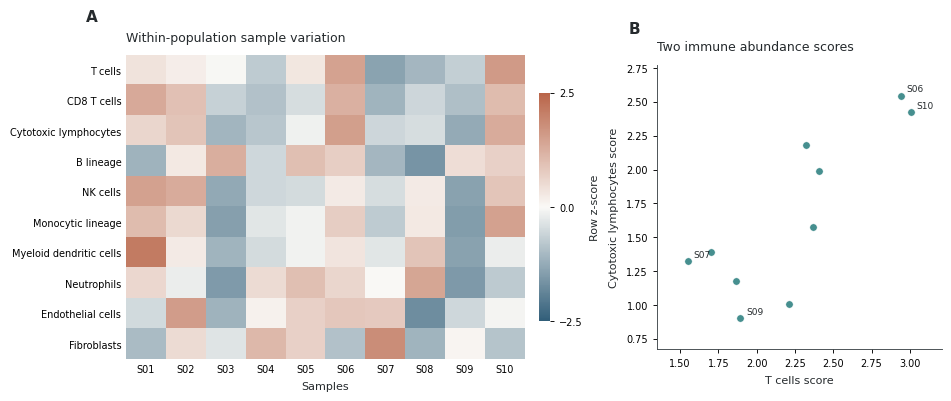

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(9.4, 3.9), gridspec_kw={"width_ratios": [1.4, 1]}, layout="constrained")
heatmap(axes[0], result, max_rows=10, max_samples=10)
names = list(result.index)
xname = next((x for x in names if str(x) == "T cells"), names[0])
yname = next((x for x in names if "Cytotoxic" in str(x)), names[1])
scatter(axes[1], result.loc[xname].to_numpy(), result.loc[yname].to_numpy(), str(xname) + " score", str(yname) + " score", annotate=True)
axes[1].set_box_aspect(1)
panel(axes[0], "A", "Within-population sample variation")
panel(axes[1], "B", "Two immune abundance scores")
save_figure(fig, '10_mcpcounter')


In [6]:
sample_ids = expression.columns if "expression" in globals() else counts.columns if "counts" in globals() else tpm.columns
display(pd.DataFrame({"plot_label": short_samples(sample_ids), "original_sample_id": sample_ids}).head(30))

,plot_label,original_sample_id
0,S01,TCGA-BR-6455
1,S02,TCGA-BR-7196
2,S03,TCGA-BR-8371
3,S04,TCGA-BR-8380
4,S05,TCGA-BR-8592
5,S06,TCGA-BR-8686
6,S07,TCGA-BR-A4IV
7,S08,TCGA-BR-A4J4
8,S09,TCGA-BR-A4J9
9,S10,TCGA-FP-7916


## 4. Interpretation and limits / 解读与边界

MCP-counter produces abundance scores, not fractions. Compare a given population across samples, rather than interpreting scores across different populations as percentages. Heatmap row scaling is a visualization transform only.

**Reusing this tutorial:** replace the input-loading cell with your own `pd.read_csv(..., index_col=0)`; keep the matrix orientation, identifier type and expression scale consistent with this example. Check gene overlap before interpreting estimates.

Figures are written to `tutorials/figures/10_mcpcounter.png`, `.pdf`, and `.svg`. Compact output tables and timing metadata are written to `tutorials/results/`. Large count/TPM matrices remain in `result`; save them explicitly with `result.to_parquet(...)` if needed.